# Предобработка датасета Common-Voice

## Этап-1. Работа с исходным датасетом.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("common-voice/validated.tsv", sep='\t')
display(data.head(2))
display(data.info())

C:\Users\maksi\AppData\Local\Temp\ipykernel_9004\150456740.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("common-voice/validated.tsv", sep='\t')


,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,01648c1613193e9f272373de6867c358d542ae833de4da...,common_voice_ru_26587318.mp3,83c950bce49b612ff614ed9d9522c1934f4e5b564ab524...,"К сожалению, эти предложения не нашли отражени...",NaN,2,0,NaN,NaN,NaN,NaN,ru,NaN
1,02e1bc351debae39ddf3d326476f7b83ad483a858e725d...,common_voice_ru_38513379.mp3,883f73b256ec7049e60d4c19121eb1ddadb734a228937a...,"Эти меры важны для того, чтобы базировать посл...",NaN,2,1,NaN,NaN,говорю как дурной подносовой прикольчик,NaN,ru,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173750 entries, 0 to 173749
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   client_id        173750 non-null  object 
 1   path             173750 non-null  object 
 2   sentence_id      173750 non-null  object 
 3   sentence         173750 non-null  object 
 4   sentence_domain  14 non-null      object 
 5   up_votes         173750 non-null  int64  
 6   down_votes       173750 non-null  int64  
 7   age              134157 non-null  object 
 8   gender           132266 non-null  object 
 9   accents          26609 non-null   object 
 10  variant          0 non-null       float64
 11  locale           173750 non-null  object 
 12  segment          2077 non-null    object 
dtypes: float64(1), int64(2), object(10)
memory usage: 17.2+ MB


None

In [4]:
# оставляем только надёжные (с точки зрения оценщиков) записи 
data = data[data['up_votes'] - data['down_votes'] > 1]


# оставляем только нужные столбцы
data = data[['client_id', 'path', 'sentence', 'gender']]

In [5]:
# Удаляем non-binary записи 
data = data[data['gender'] != 'non-binary']

# Переименовываем значения
data['gender'] = data['gender'].map({'male_masculine': 'male', 'female_feminine': 'female'})

In [6]:
durations_df = pd.read_csv("common-voice/clip_durations.tsv", sep='\t')
durations_df = durations_df.rename(columns={'clip': 'path'})
data = data.merge(durations_df, on='path')

In [7]:
# оставляем только записи с длительностью от 4.5 до 10 секунд
data = data[(data['duration[ms]'] >= 4500) & (data['duration[ms]'] <= 20_000)]
data

,client_id,path,sentence,gender,duration[ms]
0,01648c1613193e9f272373de6867c358d542ae833de4da...,common_voice_ru_26587318.mp3,"К сожалению, эти предложения не нашли отражени...",NaN,5868
1,030aa7c228c8d01cc816354d097471e18b8a1caae8a52d...,common_voice_ru_41631406.mp3,Я стоял с поднятыми плечами от внутреннего хол...,NaN,5580
2,0371548939227335ee65bbe0e40f05bc65c75d1e6f4cb5...,common_voice_ru_36292648.mp3,"Толпа озвереет, будет тереться, ощетинит ножки...",NaN,5976
3,081340f4cbaab50d8b9606a52488eb0614edd77eb782a4...,common_voice_ru_19468869.mp3,"Если не будет возражений, я буду считать, что ...",NaN,10080
6,08ce6bb4ac95d3cb2e5b0f1a54ac93d065d41caede4889...,common_voice_ru_31928067.mp3,Да ты зачем собственно приехал?,NaN,4680
...,...,...,...,...,...
160897,1d616fa1b36f41495749a7364a4a1736a589375a5400d7...,common_voice_ru_40210286.mp3,"Разведите костры, накопайте ям и уничтожьте, п...",NaN,5256
160901,1d616fa1b36f41495749a7364a4a1736a589375a5400d7...,common_voice_ru_40210298.mp3,"Они ставят себя выше других, пользуются особым...",NaN,6408
160902,1d616fa1b36f41495749a7364a4a1736a589375a5400d7...,common_voice_ru_40210299.mp3,Мы должны также добиваться укрепления подотчет...,NaN,4788
160903,1d616fa1b36f41495749a7364a4a1736a589375a5400d7...,common_voice_ru_40210305.mp3,В качестве настоятельной необходимости выступа...,NaN,7668


In [8]:
valid_clients = []

for _, df in data.groupby('client_id'):
    if len(df) >= 12:
        valid_clients.append(df)

In [9]:
data = pd.concat(valid_clients)
data

,client_id,path,sentence,gender,duration[ms]
34394,003199b017d556d7b9d5482c09f0889c8ca821a59ad396...,common_voice_ru_30614538.mp3,"А мы думаем, что у нас может быть что-нибудь в...",NaN,9036
34395,003199b017d556d7b9d5482c09f0889c8ca821a59ad396...,common_voice_ru_30614555.mp3,Да вообще-то есть... ну ладно!,male,4716
34396,003199b017d556d7b9d5482c09f0889c8ca821a59ad396...,common_voice_ru_30614557.mp3,Анна имела способность краснеть.,male,4680
34398,003199b017d556d7b9d5482c09f0889c8ca821a59ad396...,common_voice_ru_30614566.mp3,"Но рана оказалась, к несчастью для него, легкой.",male,5436
34401,003199b017d556d7b9d5482c09f0889c8ca821a59ad396...,common_voice_ru_30614576.mp3,После концертов оно любило поужинать.,male,5400
...,...,...,...,...,...
16492,fff7822c54459011c7e2054e9c61279c1d3244bc615ab1...,common_voice_ru_21637754.mp3,Я позволю себе сделать несколько вступительных...,NaN,5640
16493,fff7822c54459011c7e2054e9c61279c1d3244bc615ab1...,common_voice_ru_21637755.mp3,В них — слагаемые нашего общего успеха.,NaN,4824
16494,fff7822c54459011c7e2054e9c61279c1d3244bc615ab1...,common_voice_ru_21637756.mp3,Работа по восходящему направлению — процесс го...,NaN,8064
16495,fff7822c54459011c7e2054e9c61279c1d3244bc615ab1...,common_voice_ru_21637757.mp3,"Мы должны обеспечить, чтобы Организация Объеди...",NaN,9048


In [11]:
len(data['client_id'].unique())

690

In [14]:
client_id_to_idx = dict()

client_ids = data['client_id'].unique()

current_idx = 0
for client_id in client_ids:
    client_id_to_idx[client_id] = current_idx
    current_idx += 1

data['client_id'] = data['client_id'].apply(lambda x: client_id_to_idx[x])
data = data.rename(columns={'client_id': 'spk_id'})
data

,spk_id,path,sentence,gender,duration[ms]
34394,0,common_voice_ru_30614538.mp3,"А мы думаем, что у нас может быть что-нибудь в...",NaN,9036
34395,0,common_voice_ru_30614555.mp3,Да вообще-то есть... ну ладно!,male,4716
34396,0,common_voice_ru_30614557.mp3,Анна имела способность краснеть.,male,4680
34398,0,common_voice_ru_30614566.mp3,"Но рана оказалась, к несчастью для него, легкой.",male,5436
34401,0,common_voice_ru_30614576.mp3,После концертов оно любило поужинать.,male,5400
...,...,...,...,...,...
16492,689,common_voice_ru_21637754.mp3,Я позволю себе сделать несколько вступительных...,NaN,5640
16493,689,common_voice_ru_21637755.mp3,В них — слагаемые нашего общего успеха.,NaN,4824
16494,689,common_voice_ru_21637756.mp3,Работа по восходящему направлению — процесс го...,NaN,8064
16495,689,common_voice_ru_21637757.mp3,"Мы должны обеспечить, чтобы Организация Объеди...",NaN,9048


In [15]:
data['gender'] = data['gender'].fillna("unknown")

In [17]:
spk_to_gender = dict()

for spk_id, spk_df in data.groupby('spk_id'):
    gender_values = set(spk_df['gender'].unique())

    if 'male' in gender_values and 'female' in gender_values:
        spk_to_gender[spk_id] = 'unknown'
    
    elif 'male' in gender_values:
        spk_to_gender[spk_id] = 'male'
    
    elif 'female' in gender_values:
        spk_to_gender[spk_id] = 'female'
    
    else:
        spk_to_gender[spk_id] = 'unknown'

In [64]:
speakers_data = pd.DataFrame(list(spk_to_gender.items()), columns=['spk_id', 'gender'])
speakers_data = speakers_data.set_index('spk_id')
speakers_data

,gender
spk_id,
0,male
1,male
2,unknown
3,female
4,male
...,...
685,male
686,male
687,male


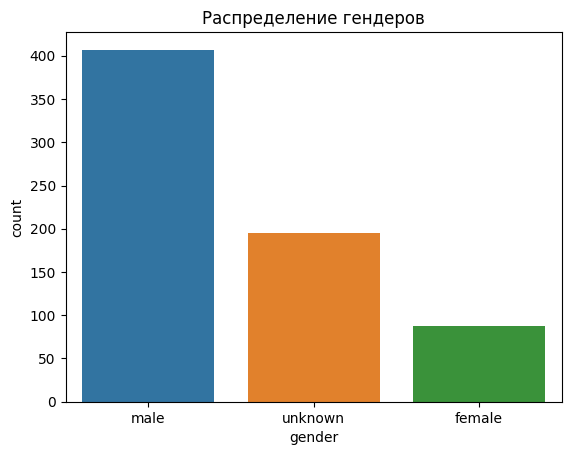

In [24]:
plt.title("Распределение гендеров")
sns.countplot(data=spk_df, x='gender', hue='gender')
plt.show()

In [65]:
speakers_data.to_csv("dataset/speakers_gender.csv")

In [29]:
frames = []

for spk_id, spk_df in data.groupby('spk_id'):
    spk_df = spk_df.iloc[:12]
    spk_df = spk_df[['spk_id', 'path', 'sentence']]
    spk_df = spk_df.rename(columns={'path': 'audio', 'sentence': 'text'})
    spk_df['clone_with'] = ['F5-TTS', 'XTTS-v2', 'Qwen-TTS'] * 4
    spk_df['audio_filter'] = [True] * 6 + [False] * 6
    frames.append(spk_df)

In [31]:
data = pd.concat(frames)

In [32]:
data

,spk_id,audio,text,clone_with,audio_filter
34394,0,common_voice_ru_30614538.mp3,"А мы думаем, что у нас может быть что-нибудь в...",F5-TTS,True
34395,0,common_voice_ru_30614555.mp3,Да вообще-то есть... ну ладно!,XTTS-v2,True
34396,0,common_voice_ru_30614557.mp3,Анна имела способность краснеть.,Qwen-TTS,True
34398,0,common_voice_ru_30614566.mp3,"Но рана оказалась, к несчастью для него, легкой.",F5-TTS,True
34401,0,common_voice_ru_30614576.mp3,После концертов оно любило поужинать.,XTTS-v2,True
...,...,...,...,...,...
16479,689,common_voice_ru_21632810.mp3,"Никакой проблемы, связанной с южнокорейскими н...",XTTS-v2,False
16480,689,common_voice_ru_21632811.mp3,Высокую оценку получили участие в обсуждениях ...,Qwen-TTS,False
16481,689,common_voice_ru_21632825.mp3,Международное сообщество предлагает нам включи...,F5-TTS,False
16482,689,common_voice_ru_21632826.mp3,Другие лидеры также выразили свою приверженнос...,XTTS-v2,False


## Этап-2. Предобработка аудио

In [39]:
from df.enhance import enhance, init_df, load_audio, save_audio
from df.utils import download_file


model, df_state, _ = init_df()


def enhance_audio(input_path: str, output_path: str) -> None:
    """
    Выполняет очистку аудиофайла
    """
    audio, _ = load_audio(input_path, sr=df_state.sr()) 

    enhanced = enhance(model, df_state, audio)

    save_audio(output_path, enhanced, df_state.sr())

2026-01-30 23:38:59 | INFO     | DF | Running on torch 2.8.0+cpu
2026-01-30 23:38:59 | INFO     | DF | Running on host DESKTOP-0VJM9O3
2026-01-30 23:39:00 | INFO     | DF | Loading model settings of DeepFilterNet3
2026-01-30 23:39:00 | INFO     | DF | Using DeepFilterNet3 model at C:\Users\maksi\AppData\Local\DeepFilterNet\DeepFilterNet\Cache\DeepFilterNet3
2026-01-30 23:39:00 | INFO     | DF | Initializing model `deepfilternet3`
2026-01-30 23:39:00 | INFO     | DF | Found checkpoint C:\Users\maksi\AppData\Local\DeepFilterNet\DeepFilterNet\Cache\DeepFilterNet3\checkpoints\model_120.ckpt.best with epoch 120


c:\Users\maksi\miniconda3\envs\deepfilter-env\lib\site-packages\df\io.py:9: UserWarning: `torchaudio.backend.common.AudioMetaData` has been moved to `torchaudio.AudioMetaData`. Please update the import path.
  from torchaudio.backend.common import AudioMetaData


2026-01-30 23:39:00 | INFO     | DF | Running on device cpu
2026-01-30 23:39:00 | INFO     | DF | Model loaded


In [35]:
import os

In [49]:
AUDIOS_PATH = "dataset/real/"


if not os.path.exists(AUDIOS_PATH):
    os.makedirs(AUDIOS_PATH)

In [50]:
import warnings

warnings.filterwarnings('ignore')

In [51]:
from tqdm.auto import tqdm
import tempfile


def get_audio_filename(audio_idx: int) -> str:
    len_ = len(str(audio_idx))
    audio_filename = '0'*(6 - len_) + str(audio_idx) + '.wav'
    return audio_filename


current_audio_idx = 1
audios = []

cleaned_cnt = 0
not_cleaned_cnt = 0
cleaned = []
not_cleaned = []

for sample in tqdm(data.iloc):
    audio_name = get_audio_filename(current_audio_idx)
    audio_path = os.path.join(AUDIOS_PATH, audio_name)

    if not sample['audio_filter']:
        wav, sr = torchaudio.load(f"common-voice/clips/{sample['audio']}")
        torchaudio.save(audio_path, wav, sr)

        not_cleaned_cnt += 1
        not_cleaned.append(audio_name)
    
    else:
        temp_file = './temp.wav'

        wav, sr = torchaudio.load(f"common-voice/clips/{sample['audio']}")
        wav = torchaudio.transforms.Resample(sr, 48_000)(wav)
        torchaudio.save(temp_file, wav, 48_000)

        enhance_audio(temp_file, audio_path)

        cleaned_cnt += 1
        cleaned.append(audio_name)

    audios.append(audio_name)
    current_audio_idx += 1

8280it [28:47,  4.79it/s]


In [54]:
assert cleaned_cnt == not_cleaned_cnt, "Что-то не так!"

In [57]:
data['audio'] = audios
data

,spk_id,audio,text,clone_with,audio_filter
34394,0,000001.wav,"А мы думаем, что у нас может быть что-нибудь в...",F5-TTS,True
34395,0,000002.wav,Да вообще-то есть... ну ладно!,XTTS-v2,True
34396,0,000003.wav,Анна имела способность краснеть.,Qwen-TTS,True
34398,0,000004.wav,"Но рана оказалась, к несчастью для него, легкой.",F5-TTS,True
34401,0,000005.wav,После концертов оно любило поужинать.,XTTS-v2,True
...,...,...,...,...,...
16479,689,008276.wav,"Никакой проблемы, связанной с южнокорейскими н...",XTTS-v2,False
16480,689,008277.wav,Высокую оценку получили участие в обсуждениях ...,Qwen-TTS,False
16481,689,008278.wav,Международное сообщество предлагает нам включи...,F5-TTS,False
16482,689,008279.wav,Другие лидеры также выразили свою приверженнос...,XTTS-v2,False


In [59]:
data.index = range(len(data))

In [61]:
data.to_csv("dataset/real.csv")

## Этап-3. Генерация чанков для синтеза речи

Чтобы было проще и эффективнее проводить синтез речи, разобьем данные на чанки и будем проводить синтез по ним.

Важно определить, какой текст будут произносить клоны. Предлагается следующая стратегия:
- половина клонов будут произносить тот же текст, что и оригинал
- половина клонов будут произносить другой текст, случайный из набора данных
- в рамках одного спикера и определённой модели синтеза одинаковый текст будет использоваться для одной очищенной записи, и для одной неочищенной записи для баланса.

In [1]:
import pandas as pd


data = pd.read_csv("dataset/real.csv", index_col=0)

In [2]:
data.head(12)

,spk_id,audio,text,clone_with,audio_filter
0,0,000001.wav,"А мы думаем, что у нас может быть что-нибудь в...",F5-TTS,True
1,0,000002.wav,Да вообще-то есть... ну ладно!,XTTS-v2,True
2,0,000003.wav,Анна имела способность краснеть.,Qwen-TTS,True
3,0,000004.wav,"Но рана оказалась, к несчастью для него, легкой.",F5-TTS,True
4,0,000005.wav,После концертов оно любило поужинать.,XTTS-v2,True
5,0,000006.wav,"Что было написано там такое печальное, такое г...",Qwen-TTS,True
6,0,000007.wav,Бекасов оказалось очень много.,F5-TTS,False
7,0,000008.wav,Я с ненавистью посмотрел на старуху.,XTTS-v2,False
8,0,000009.wav,"Теперь пойдём, свернув табак собачей ножкой.",Qwen-TTS,False
9,0,000010.wav,"Мать частенько голодала, а девица пила и ела з...",F5-TTS,False


In [3]:
speakers_count = len(data['spk_id'].unique())

data['use_same_text'] = [1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0] * speakers_count

In [4]:
data

,spk_id,audio,text,clone_with,audio_filter,use_same_text
0,0,000001.wav,"А мы думаем, что у нас может быть что-нибудь в...",F5-TTS,True,1
1,0,000002.wav,Да вообще-то есть... ну ладно!,XTTS-v2,True,1
2,0,000003.wav,Анна имела способность краснеть.,Qwen-TTS,True,1
3,0,000004.wav,"Но рана оказалась, к несчастью для него, легкой.",F5-TTS,True,0
4,0,000005.wav,После концертов оно любило поужинать.,XTTS-v2,True,0
...,...,...,...,...,...,...
8275,689,008276.wav,"Никакой проблемы, связанной с южнокорейскими н...",XTTS-v2,False,1
8276,689,008277.wav,Высокую оценку получили участие в обсуждениях ...,Qwen-TTS,False,1
8277,689,008278.wav,Международное сообщество предлагает нам включи...,F5-TTS,False,0
8278,689,008279.wav,Другие лидеры также выразили свою приверженнос...,XTTS-v2,False,0


In [5]:
import random


all_texts = data['text'].unique()


def create_clone_text(row):
    if row['use_same_text']:
        return row['text']
    
    else:
        clone_text = row['text']
        while clone_text == row['text']:
            clone_text = random.choice(all_texts)
        return clone_text


data['clone_text'] = data.apply(lambda x: create_clone_text(x), axis=1)

In [6]:
data

,spk_id,audio,text,clone_with,audio_filter,use_same_text,clone_text
0,0,000001.wav,"А мы думаем, что у нас может быть что-нибудь в...",F5-TTS,True,1,"А мы думаем, что у нас может быть что-нибудь в..."
1,0,000002.wav,Да вообще-то есть... ну ладно!,XTTS-v2,True,1,Да вообще-то есть... ну ладно!
2,0,000003.wav,Анна имела способность краснеть.,Qwen-TTS,True,1,Анна имела способность краснеть.
3,0,000004.wav,"Но рана оказалась, к несчастью для него, легкой.",F5-TTS,True,0,Эти четыре проблемы олицетворяют собой как нов...
4,0,000005.wav,После концертов оно любило поужинать.,XTTS-v2,True,0,Для этого и создаются централизованные учрежде...
...,...,...,...,...,...,...,...
8275,689,008276.wav,"Никакой проблемы, связанной с южнокорейскими н...",XTTS-v2,False,1,"Никакой проблемы, связанной с южнокорейскими н..."
8276,689,008277.wav,Высокую оценку получили участие в обсуждениях ...,Qwen-TTS,False,1,Высокую оценку получили участие в обсуждениях ...
8277,689,008278.wav,Международное сообщество предлагает нам включи...,F5-TTS,False,0,"Надо еще и подгонять, подбирать параметры како..."
8278,689,008279.wav,Другие лидеры также выразили свою приверженнос...,XTTS-v2,False,0,"По сути, четыре проекта резолюций касаются поз..."


In [7]:
data.to_csv('dataset/real.csv')

In [9]:
data['is_done'] = [False] * len(data)

f5_tts_df = data[data['clone_with']=='F5-TTS']
xtts_df = data[data['clone_with']=='XTTS-v2']
qwen_tts_df = data[data['clone_with']=='Qwen-TTS']

In [12]:
import os 


os.makedirs("f5_tts_chunks/")
os.makedirs("xtts_chunks/")
os.makedirs("qwen_tts_chunks/")


f5_tts_chunks = []
xtts_chunks = []
qwen_tts_chunks = []


for i in range(10):
    f5_tts_df.iloc[i::10].to_csv(f"f5_tts_chunks/{i}.csv")
    xtts_df.iloc[i::10].to_csv(f"xtts_chunks/{i}.csv")
    qwen_tts_df.iloc[i::10].to_csv(f"qwen_tts_chunks/{i}.csv")